# Soil Texture from Spectra

**GeoAI LAB** - predicting sand, silt and clay from VisNIR reflectance spectra.

Needs only the three CSVs beside it. Runs top to bottom. Each cell is labelled with the
task it answers.

Sections: 0 setup | 1 exploration (1.1-1.15) | 2 sensors (2.1-2.5) | 3 before modelling
(3.1-3.3) | 4 first model (4.1-4.4) | 5 validation (5.1-5.4) | 6 explainability (6.1-6.6)

## 0 - Setup

Two things found in 1.2 that shape everything after:

- **`L400`-`L450` is missing for all 22 171 LUCAS rows** (its instrument starts at 455 nm).
  So `SPEC` (421 columns) is used for plots, and `SPEC410` (455-2500 nm) for all maths.
- **Two rows are dead spectra** - reflectance 1.0 everywhere. `VALID` drops them.

In [1]:
# setup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset = pd.read_csv("ossl_tp_dataset.csv", low_memory=False)
soillab = pd.read_csv("ossl_tp_soillab.csv", low_memory=False)
soilsite = pd.read_csv("ossl_tp_soilsite.csv", low_memory=False)

SPEC = sorted([c for c in dataset.columns if re.fullmatch(r"L\d+", c)], key=lambda c: int(c[1:]))
WL = np.array([int(c[1:]) for c in SPEC])
META = [c for c in dataset.columns if c not in SPEC]
TARGETS = ["sand", "silt", "clay"]
PROGS = ["ICRAF.ISRIC", "KSSL.SSL", "LUCAS.SSL"]
COLORS = {"ICRAF.ISRIC": "#1b7f79", "KSSL.SSL": "#c1553b", "LUCAS.SSL": "#3d5a99",
          "sand": "#c98b3b", "silt": "#4a8c6f", "clay": "#8c4a6f"}

A = dataset[SPEC].to_numpy()                       # spectra, with NaN
SPEC410 = [c for c in SPEC if dataset[c].notna().all()]
WL410 = np.array([int(c[1:]) for c in SPEC410])
VALID = np.nanstd(A, axis=1) > 0                   # False for the two dead spectra
X = dataset.loc[VALID, SPEC410].to_numpy()         # clean matrix used for all maths

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

def save_fig(task):
    plt.savefig(f"figs/fig_{task.replace('.', '_')}.png")

print(f"SPEC {len(SPEC)} columns | SPEC410 {len(SPEC410)} columns | dead rows {(~VALID).sum()}")

SPEC 421 columns | SPEC410 410 columns | dead rows 2


## 1 - Data exploration

### 1.1 - Size and columns &nbsp;&nbsp;|&nbsp;&nbsp; 1.2 - Missing values, duplicates, ranges

**Deliverables:** shape + column list; 1 summary table.

In [2]:
# tasks 1.1 and 1.2
print("dataset ", dataset.shape, " soillab", soillab.shape, " soilsite", soilsite.shape)
print("metadata:", META)
print("spectra :", SPEC[0], "..", SPEC[-1], "- reflectance every 5 nm\n")

summary = dataset[META].describe(include="all").T[["count", "min", "max"]]
summary["missing"] = dataset[META].isna().sum()
summary.loc["L400-L450 (11 cols)"] = [len(dataset) * 11 - np.isnan(A[:, :11]).sum(),
                                      np.nanmin(A[:, :11]), np.nanmax(A[:, :11]),
                                      np.isnan(A[:, :11]).sum()]
summary.loc["L455-L2500 (410 cols)"] = [len(dataset) * 410, np.nanmin(X), np.nanmax(X), 0]
summary.to_csv("tables/table_1_2.csv")
summary

dataset  (40535, 433)  soillab (40535, 58)  soilsite (40535, 36)
metadata: ['id', 'programme', 'instrument', 'prof_haut', 'prof_bas', 'sand', 'silt', 'clay', 'classe_usda', 'lon', 'lat', 'n_scans']
spectra : L400 .. L2500 - reflectance every 5 nm



,count,min,max,missing
id,40535,NaN,NaN,0.0
programme,40535,NaN,NaN,0.0
instrument,40535,NaN,NaN,0.0
prof_haut,40535.0,0.0,278.0,0.0
prof_bas,40535.0,1.0,300.0,0.0
sand,40535.0,0.0,100.0,0.0
silt,40535.0,0.0,94.4806,0.0
clay,40535.0,0.0,96.8969,0.0
classe_usda,40535,NaN,NaN,0.0
lon,40037.0,-172.3633,153.017,498.0


In [3]:
# task 1.2: duplicates and ranges
print("duplicate ids     :", dataset["id"].duplicated().sum())
print("duplicate spectra :", dataset.duplicated(subset=SPEC).sum(),
      "- but 0 once targets are included, so they carry different texture values")
print("reflectance range :", np.nanmin(A).round(3), "-", np.nanmax(A).round(3))
print("dead spectra      :", (~VALID).sum(), "rows are reflectance 1.0 at all 421 wavelengths")
print("missing lon/lat   :", dataset["lon"].isna().sum())
print("missing L400      :", dataset["L400"].isna().sum(), "- all of them LUCAS")

duplicate ids     : 0


duplicate spectra : 11 - but 0 once targets are included, so they carry different texture values
reflectance range : 0.02 - 1.0
dead spectra      : 2 rows are reflectance 1.0 at all 421 wavelengths
missing lon/lat   : 498
missing L400      : 22171 - all of them LUCAS


### 1.3 - Twenty spectra &nbsp;|&nbsp; 1.4 - Mean ±1 SD &nbsp;|&nbsp; 1.5 - Mean per programme

**Deliverables:** 3 figures. The grey band marks the wavelengths LUCAS does not measure.

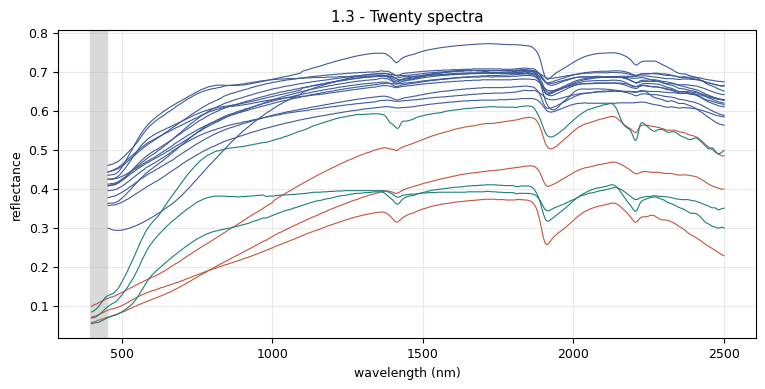

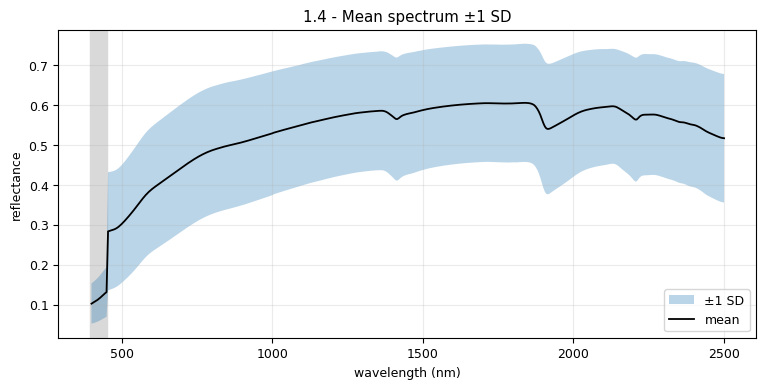

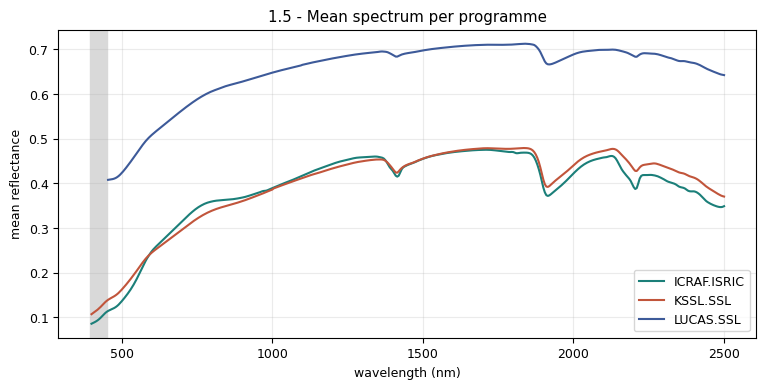

instrument   ASD_FieldSpec  ASD_LabSpec    XDS
programme                                     
ICRAF.ISRIC           3636            0      0
KSSL.SSL                 0        14728      0
LUCAS.SSL                0            0  22171
-> each programme used exactly one instrument: the two cannot be separated.


In [4]:
# 1.3: twenty spectra
idx = np.random.default_rng(0).choice(len(dataset), 20, replace=False)
plt.figure(figsize=(9, 4))
for i in idx:
    plt.plot(WL, A[i], lw=0.8, color=COLORS[dataset["programme"].iloc[i]])
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.title("1.3 - Twenty spectra")
save_fig("1.3"); plt.show()

# 1.4:  mean and sd
mean, sd = np.nanmean(A, axis=0), np.nanstd(A, axis=0)
plt.figure(figsize=(9, 4))
plt.fill_between(WL, mean - sd, mean + sd, alpha=0.3, label="±1 SD")
plt.plot(WL, mean, color="black", lw=1.3, label="mean")
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.legend()
plt.title("1.4 - Mean spectrum ±1 SD"); save_fig("1.4"); plt.show()

# 1.5: one curve per programme
means = dataset.groupby("programme")[SPEC].mean()
plt.figure(figsize=(9, 4))
for p in PROGS:
    plt.plot(WL, means.loc[p], color=COLORS[p], label=p)
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("mean reflectance"); plt.legend()
plt.title("1.5 - Mean spectrum per programme"); save_fig("1.5"); plt.show()

print(pd.crosstab(dataset["programme"], dataset["instrument"]))
print("-> each programme used exactly one instrument: the two cannot be separated.")

### 1.6 - PCA &nbsp;&nbsp;|&nbsp;&nbsp; 1.7 - Correlation between neighbouring wavelengths

**Deliverables:** number of components reaching 95%; 1 number.

PCA is run on `SPEC410` (it cannot accept NaN) and mean-centred, not standardised: all
columns are the same quantity in the same unit.

ANSWER 1.6: 1 component reaches 95% of the variance
  PC1 alone = 95.43 %
  PC1's loadings all have the same sign -> PC1 is brightness, not texture

ANSWER 1.7: r(L1000, L1005) = 0.999944
  neighbouring wavelengths are near-identical, which is why 1 component is enough


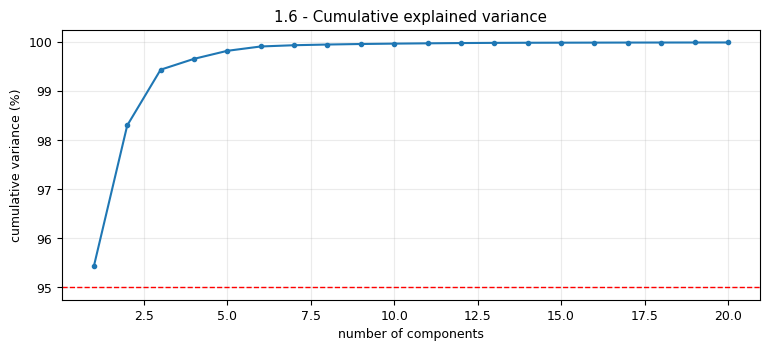

In [5]:
from sklearn.decomposition import PCA

pca = PCA().fit(X)
cumulative = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(cumulative >= 0.95) + 1
print("ANSWER 1.6:", n95, "component reaches 95% of the variance")
print("  PC1 alone =", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("  PC1's loadings all have the same sign -> PC1 is brightness, not texture")

r = np.corrcoef(dataset["L1000"], dataset["L1005"])[0, 1]
print("\nANSWER 1.7: r(L1000, L1005) =", round(r, 6))
print("  neighbouring wavelengths are near-identical, which is why 1 component is enough")

plt.figure(figsize=(9, 3.5))
plt.plot(range(1, 21), cumulative[:20] * 100, marker="o", ms=3)
plt.axhline(95, color="red", ls="--", lw=1)
plt.xlabel("number of components"); plt.ylabel("cumulative variance (%)")
plt.title("1.6 - Cumulative explained variance"); save_fig("1.6"); plt.show()

### 1.8 - Distributions &nbsp;|&nbsp; 1.9 - Sum of fractions &nbsp;|&nbsp; 1.10 - Texture triangle &nbsp;|&nbsp; 1.11 - Class counts

**Deliverables:** 1 figure; min/mean/max; 1 figure; 1 table.

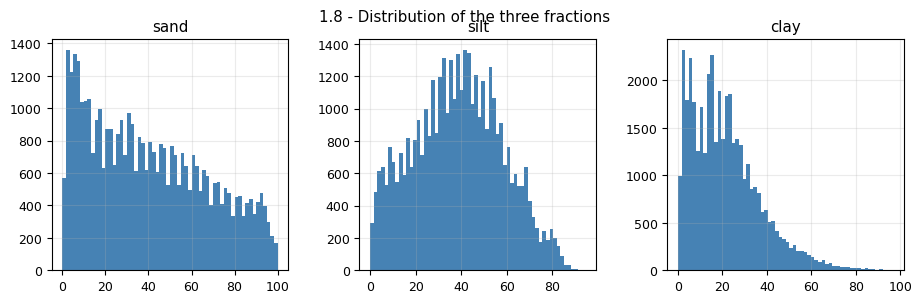

           sand      silt      clay
count  40535.00  40535.00  40535.00
mean      40.05     38.56     21.39
std       27.35     19.39     15.38
min        0.00      0.00      0.00
25%       15.90     24.01      9.09
50%       36.36     38.82     19.00
75%       61.09     52.53     29.97
max      100.00     94.48     96.90

ANSWER 1.9: min 99.9999  mean 100.0  max 100.0001
  The fractions already sum to 100 (not to 1), so only two of them are independent.
  Task 4.3's '2% from 1' therefore means 2 points away from 100.


In [6]:
# tasks 1.8 and 1.9
dataset[TARGETS].hist(bins=60, figsize=(11, 3), layout=(1, 3), color="steelblue")
plt.suptitle("1.8 - Distribution of the three fractions")
save_fig("1.8"); plt.show()
print(dataset[TARGETS].describe().round(2))

total = dataset[TARGETS].sum(axis=1)
print("\nANSWER 1.9: min", round(total.min(), 4), " mean", round(total.mean(), 4),
      " max", round(total.max(), 4))
print("  The fractions already sum to 100 (not to 1), so only two of them are independent.")
print("  Task 4.3's '2% from 1' therefore means 2 points away from 100.")

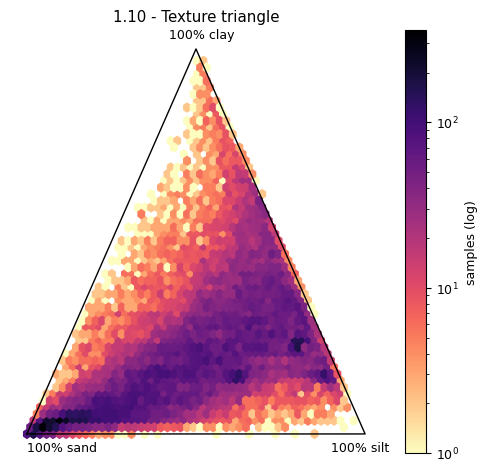

ANSWER 1.11: 12 classes, largest/smallest = 57 x


classe_usda
Silt loam          7847
Sandy loam         7660
Loam               6488
Silty clay loam    4070
Clay loam          2955
Clay               2773
Sand               2660
Loamy sand         2617
Silty clay         2019
Sandy clay loam    1163
Silt                146
Sandy clay          137
Name: count, dtype: int64

In [7]:
# tasks 1.10 and 1.11
x = 0.5 * (2 * dataset["silt"] + dataset["clay"]) / 100
y = (np.sqrt(3) / 2) * dataset["clay"] / 100

plt.figure(figsize=(6, 5.5))
plt.hexbin(x, y, gridsize=50, bins="log", cmap="magma_r", mincnt=1)
plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color="black", lw=1)
plt.colorbar(label="samples (log)")
plt.text(0, -0.04, "100% sand"); plt.text(0.9, -0.04, "100% silt"); plt.text(0.42, 0.89, "100% clay")
plt.axis("off"); plt.title("1.10 - Texture triangle")
save_fig("1.10"); plt.show()

counts = dataset["classe_usda"].value_counts()
counts.to_csv("tables/table_1_11.csv")
print("ANSWER 1.11:", len(counts), "classes, largest/smallest =",
      round(counts.max() / counts.min()), "x")
counts

### 1.12 - Map &nbsp;|&nbsp; 1.13 - Samples and clay per programme &nbsp;|&nbsp; 1.14 - Depth

**Deliverables:** 1 figure; 1 table + 1 figure; 1 figure.

Together these show that `programme` is also a region and a depth regime.

dropped 498 rows with no coordinates


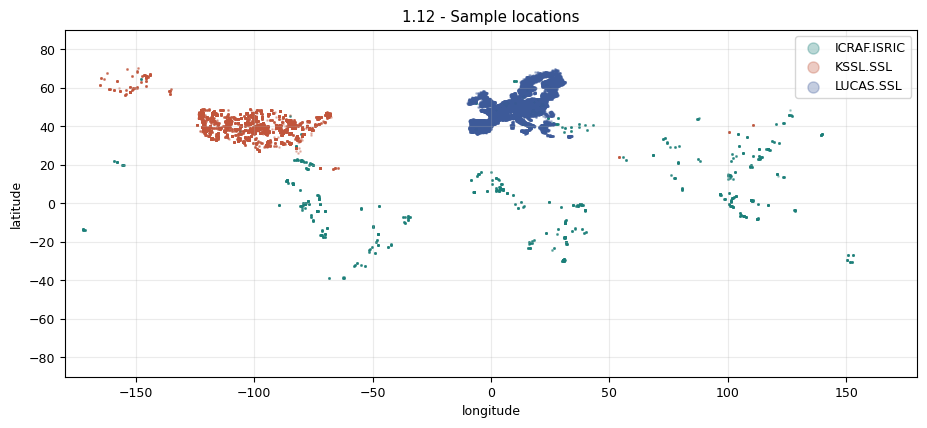

In [8]:
geo = dataset.dropna(subset=["lon", "lat"])
print("dropped", len(dataset) - len(geo), "rows with no coordinates")

plt.figure(figsize=(11, 4.5))
for p in PROGS:
    g = geo[geo["programme"] == p]
    plt.scatter(g["lon"], g["lat"], s=1, alpha=0.3, color=COLORS[p], label=p)
plt.xlim(-180, 180); plt.ylim(-90, 90); plt.xlabel("longitude"); plt.ylabel("latitude")
plt.legend(markerscale=8); plt.title("1.12 - Sample locations")
save_fig("1.12"); plt.show()

programme
LUCAS.SSL      22171
KSSL.SSL       14728
ICRAF.ISRIC     3636
Name: count, dtype: int64 



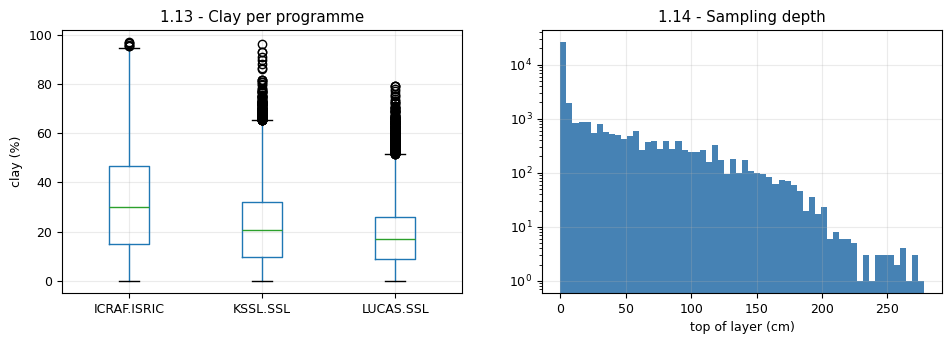

programme
ICRAF.ISRIC    40.0
KSSL.SSL       25.0
LUCAS.SSL       0.0
Name: prof_haut, dtype: float64
-> LUCAS samples the surface, ICRAF goes deeper: another difference between programmes.


In [9]:
table = dataset.groupby("programme")[["clay"]].describe().round(1)
table.to_csv("tables/table_1_13.csv")
print(dataset["programme"].value_counts(), "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
dataset.boxplot(column="clay", by="programme", ax=ax1)
ax1.set_title("1.13 - Clay per programme"); ax1.set_xlabel(""); ax1.set_ylabel("clay (%)")
dataset["prof_haut"].hist(bins=60, ax=ax2, color="steelblue")
ax2.set_yscale("log"); ax2.set_title("1.14 - Sampling depth"); ax2.set_xlabel("top of layer (cm)")
plt.suptitle("")
save_fig("1.13"); save_fig("1.14")   # one figure, but both tasks ask for one
plt.show()

print(dataset.groupby("programme")["prof_haut"].median())
print("-> LUCAS samples the surface, ICRAF goes deeper: another difference between programmes.")

### 1.15 - Correlation of every wavelength with each target

**Deliverable:** 1 figure + the peak wavelength of each target.

The peak is taken on **|r|**, because clay correlates negatively over most of the range.
The second figure repeats the calculation inside each programme - the pooled curve is weak
only because three different relationships are being averaged together.

ANSWER 1.15 - peak |r| per target (all programmes pooled):
  sand  2500 nm   r = +0.074
  silt  2170 nm   r = +0.155
  clay  2500 nm   r = -0.319


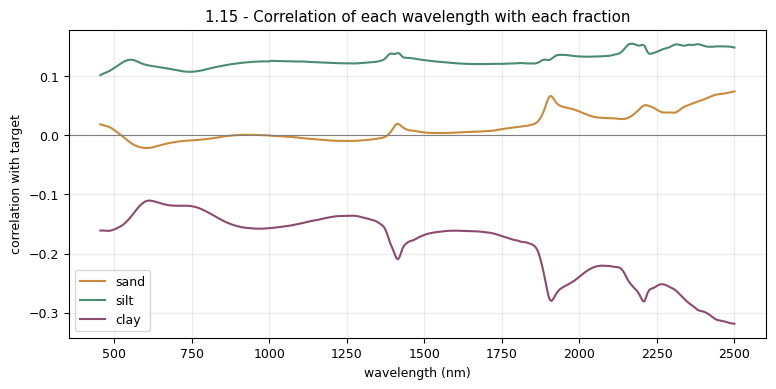

In [10]:
def correlations(rows):
    return np.array([[np.corrcoef(dataset.loc[rows, c], dataset.loc[rows, t])[0, 1]
                      for t in TARGETS] for c in SPEC410])

R = correlations(VALID)

plt.figure(figsize=(9, 4))
print("ANSWER 1.15 - peak |r| per target (all programmes pooled):")
for k, t in enumerate(TARGETS):
    plt.plot(WL410, R[:, k], color=COLORS[t], label=t)
    best = np.argmax(abs(R[:, k]))
    print(f"  {t:5s} {WL410[best]} nm   r = {R[best, k]:+.3f}")
plt.axhline(0, color="grey", lw=0.8); plt.legend()
plt.xlabel("wavelength (nm)"); plt.ylabel("correlation with target")
plt.title("1.15 - Correlation of each wavelength with each fraction")
save_fig("1.15"); plt.show()

ICRAF.ISRIC  sand  peak 1910 nm  r = +0.359
ICRAF.ISRIC  silt  peak 2205 nm  r = +0.198
ICRAF.ISRIC  clay  peak 2475 nm  r = -0.606


KSSL.SSL     sand  peak 1275 nm  r = -0.060
KSSL.SSL     silt  peak 2500 nm  r = +0.199
KSSL.SSL     clay  peak 2500 nm  r = -0.361


LUCAS.SSL    sand  peak 605 nm  r = -0.369
LUCAS.SSL    silt  peak 625 nm  r = +0.358
LUCAS.SSL    clay  peak 605 nm  r = +0.237


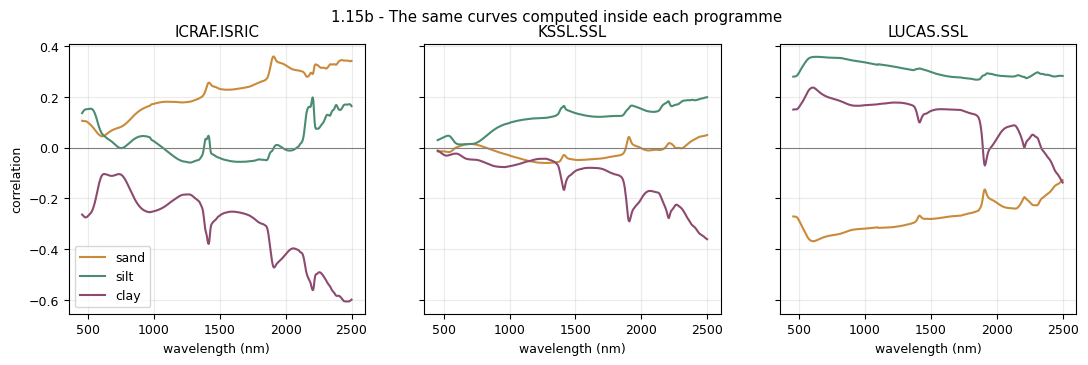

In [11]:
# 1.15
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, p in zip(axes, PROGS):
    Rp = correlations(VALID & (dataset["programme"] == p))
    for k, t in enumerate(TARGETS):
        ax.plot(WL410, Rp[:, k], color=COLORS[t], label=t)
        print(f"{p:12s} {t:5s} peak {WL410[np.argmax(abs(Rp[:, k]))]} nm  "
              f"r = {Rp[np.argmax(abs(Rp[:, k])), k]:+.3f}")
    ax.axhline(0, color="grey", lw=0.8); ax.set_title(p); ax.set_xlabel("wavelength (nm)")
axes[0].set_ylabel("correlation"); axes[0].legend()
plt.suptitle("1.15b - The same curves computed inside each programme")
save_fig("1.15b"); plt.show()

### Section 1 - answers

| Task | Answer |
|---|---|
| 1.6 | **1 component** reaches 95% (PC1 = 95.4%, and PC1 is brightness, not texture) |
| 1.7 | **r(L1000, L1005) = 0.999944** |
| 1.9 | min **99.9999**, mean **100.0000**, max **100.0001** - closed to 100 |
| 1.15 | sand **2500 nm** (+0.074), silt **2170 nm** (+0.155), clay **2500 nm** (-0.319) |

**What this means for the rest of the lab**

1. Models use `SPEC410` (455-2500 nm) and drop the two dead rows.
2. `programme` is also the instrument, the region and the depth regime. Leaving one
   programme out of training (task 5.1) changes all of these at once, so the drop in score
   it produces cannot be blamed on any single one of them.
3. One component carries 95% of 410 columns, so reducing the spectra to 12 or 175 bands in
   section 2 loses far less than the number of columns suggests.
4. The targets already sum to 100, so any gap in task 4.3 comes only from fitting the three
   fractions separately.

## 2 - Sensor simulation

A laboratory spectrometer returns a continuous curve; a satellite returns one number per
band. This section produces what two satellites would have measured for these same soils.

### 2.1 - The 12 multispectral bands &nbsp;|&nbsp; 2.2 - Bands every 12 nm

**Deliverables:** 1 table with 12 columns + the rule used; 1 table with ~175 columns.

The rule is in `resample()` below: each band is the plain average of every laboratory
wavelength inside `centre ± width/2`. `skipna=False` matters - a band that overlaps the
400-450 nm block LUCAS never measured comes out NaN, instead of being quietly computed from
whatever half of its window survived.

In [12]:
# tasks 2.1 and 2.2: simulate the two sensors
BANDS_12 = [("B1", 443, 20), ("B2", 490, 65), ("B3", 560, 35), ("B4", 665, 30),
            ("B5", 705, 15), ("B6", 740, 15), ("B7", 783, 20), ("B8", 842, 115),
            ("B8A", 865, 20), ("B9", 945, 20), ("B11", 1610, 90), ("B12", 2190, 180)]

# 12 nm wide
BANDS_HYPER = [(f"H{400 + 12 * k}", 406 + 12 * k, 12) for k in range(175)]

def resample(bands): # one number per band: the mean of the laboratory wavelengths inside it
    out = {}
    for name, centre, width in bands:
        cols = [c for c, w in zip(SPEC, WL) if abs(w - centre) <= width / 2]
        out[name] = dataset[cols].mean(axis=1, skipna=False)
    return pd.DataFrame(out)

multi = resample(BANDS_12)
hyper = resample(BANDS_HYPER)

MULTI_OK = [b for b in multi.columns if multi[b].notna().all()]
HYPER_OK = [b for b in hyper.columns if hyper[b].notna().all()]

print("multispectral:", multi.shape[1], "bands,", len(MULTI_OK), "usable")
print("  B1 covers 433-453 nm, inside the LUCAS gap ->", multi["B1"].isna().sum(), "rows are NaN")
print("hyperspectral:", hyper.shape[1], "bands,", len(HYPER_OK), "usable")
print("  unusable:", [b for b in hyper.columns if b not in HYPER_OK])
print("\nModels in sections 4-6 therefore use 11 and 170 bands, not 12 and 175.")

multi.head(50).to_csv("tables/table_2_1.csv")
multi.head()

multispectral: 12 bands, 11 usable
  B1 covers 433-453 nm, inside the LUCAS gap -> 22171 rows are NaN
hyperspectral: 175 bands, 170 usable
  unusable: ['H400', 'H412', 'H424', 'H436', 'H448']

Models in sections 4-6 therefore use 11 and 170 bands, not 12 and 175.


,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12
0,0.096995,0.117672,0.187990,0.292806,0.326957,0.354033,0.376692,0.388680,0.392590,0.410004,0.551634,0.452391
1,0.098342,0.120425,0.208143,0.351631,0.391487,0.421907,0.440555,0.438987,0.436578,0.443980,0.580952,0.439338
2,0.088445,0.108619,0.205079,0.395553,0.438503,0.472847,0.480758,0.454880,0.442138,0.440076,0.594613,0.396373
3,0.104765,0.129628,0.229689,0.456477,0.510050,0.544007,0.550763,0.525744,0.513640,0.518688,0.710175,0.419695
4,0.074370,0.092182,0.177866,0.442711,0.498010,0.534750,0.527737,0.489133,0.472690,0.491176,0.722989,0.461514


### 2.3 - One sample, three ways &nbsp;&nbsp;|&nbsp;&nbsp; 2.4 - Mean spectrum, zoomed on 1900-2500 nm

**Deliverables:** 2 figures.

The zoom is not arbitrary: 2200 nm is where clay minerals absorb, and it is where task 1.15
found clay's strongest correlation. The horizontal bars in 2.3 show how wide each
multispectral band is - B12 alone is 180 nm.

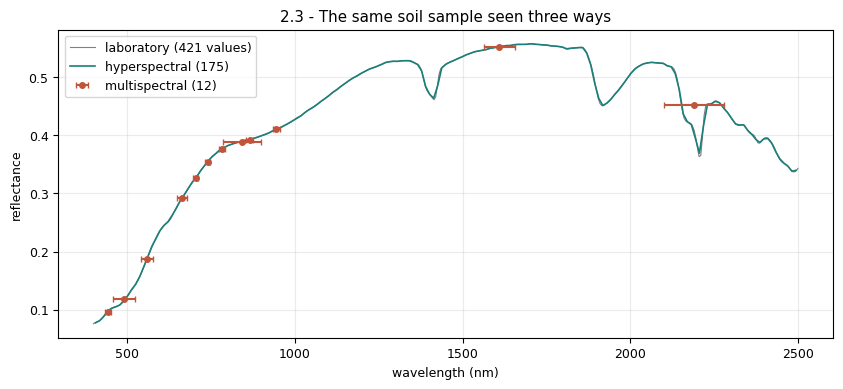

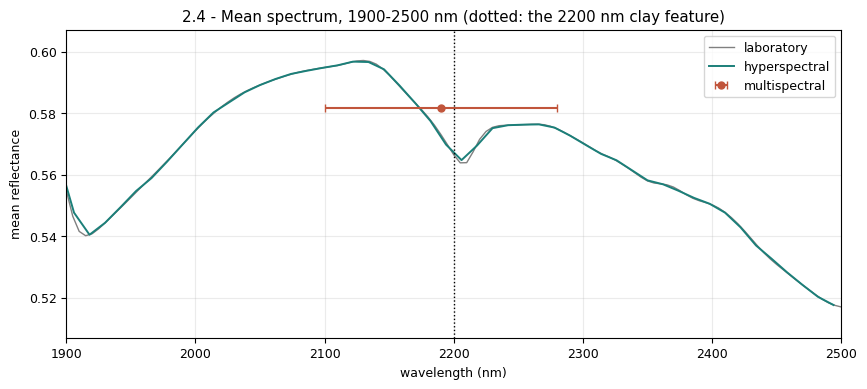

In [13]:
# tasks 2.3 and 2.4: what each sensor would have seen
centres_m = np.array([c for _, c, _ in BANDS_12])
widths_m = np.array([w for _, _, w in BANDS_12])
centres_h = np.array([c for _, c, _ in BANDS_HYPER])

plt.figure(figsize=(10, 4))
plt.plot(WL, A[0], lw=0.8, color="grey", label="laboratory (421 values)")
plt.plot(centres_h, hyper.iloc[0], lw=1.2, color="#1b7f79", label="hyperspectral (175)")
plt.errorbar(centres_m, multi.iloc[0], xerr=widths_m / 2, fmt="o", ms=4, capsize=2,
             color="#c1553b", label="multispectral (12)")
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.legend()
plt.title("2.3 - The same soil sample seen three ways")
save_fig("2.3"); plt.show()

# 2.4 - the mean spectrum, zoomed on the clay absorption region
plt.figure(figsize=(10, 4))
plt.plot(WL, np.nanmean(A, axis=0), lw=1, color="grey", label="laboratory")
plt.plot(centres_h, hyper.mean(), lw=1.4, color="#1b7f79", label="hyperspectral")
plt.errorbar(centres_m, multi.mean(), xerr=widths_m / 2, fmt="o", ms=5, capsize=3,
             color="#c1553b", label="multispectral")
win = (WL >= 1900) & (WL <= 2500)          # scale y to the zoomed window only
lab_mean = np.nanmean(A, axis=0)
plt.xlim(1900, 2500)
plt.ylim(lab_mean[win].min() - 0.01, lab_mean[win].max() + 0.01)
plt.axvline(2200, color="black", ls=":", lw=1)
plt.xlabel("wavelength (nm)"); plt.ylabel("mean reflectance"); plt.legend()
plt.title("2.4 - Mean spectrum, 1900-2500 nm (dotted: the 2200 nm clay feature)")
save_fig("2.4"); plt.show()

In [14]:
# task 2.4: how much of the 2200 nm clay feature each sensor keeps
def feature_depth(values, centres):
    at = lambda w: values[np.argmin(abs(centres - w))]
    return (at(2130) + at(2260)) / 2 - at(2200)

print("depth of the 2200 nm absorption feature")
print("  laboratory   :", round(feature_depth(np.nanmean(A, axis=0), WL), 5))
print("  hyperspectral:", round(feature_depth(hyper.mean().values, centres_h), 5))
print("  multispectral:", round(feature_depth(multi.mean().values, centres_m), 5))
print("\nThe multispectral depth is exactly zero, and not by accident: B12 spans")
print("2100-2280 nm, so the dip AND both shoulders fall inside one band. Averaging them")
print("together cancels the feature out - one number cannot describe a dip.")

depth of the 2200 nm absorption feature
  laboratory   : 0.02029


  hyperspectral: 0.01666
  multispectral: 0.0

The multispectral depth is exactly zero, and not by accident: B12 spans
2100-2280 nm, so the dip AND both shoulders fall inside one band. Averaging them
together cancels the feature out - one number cannot describe a dip.


### 2.5 - The rule, and the alternative rejected

**Deliverable:** 3 written lines.

**Rule.** Each band is the unweighted mean of every laboratory wavelength inside
`centre ± width/2` - a rectangular spectral response - and a band is left NaN if any
wavelength in its window is missing rather than being averaged from a partial window.

**Why.** It needs nothing but the band table given in the sheet; it keeps the
noise-averaging that is the reason a wide band exists at all (each band here averages 3 to
37 laboratory readings); and on a regular 5 nm grid the unweighted mean is an unbiased
estimate of the band's average reflectance.

**Rejected.** A Gaussian response weighted by each band's FWHM is closer to how a real
detector behaves, but the per-band response curves were never supplied and inventing them
would fake a precision this data does not have. Sampling the single nearest wavelength was
also rejected: it discards the averaging and would carry the noise of one 5 nm channel into
a band up to 180 nm wide.

## 3 - Before modelling

No model is fitted in this section. The point is to decide what is achievable *before* any
score exists to influence the answer.

### 3.1 - Task 1.15 redone on each simulated sensor &nbsp;|&nbsp; 3.2 - Did the information survive?

**Deliverables:** 1 figure per sensor; a 3x2 table with a reason per cell.

The correlations stay **pooled** across programmes, so they are directly comparable with
task 1.15. Remember from 1.15b that pooling dilutes them - within a single programme they
are two to eight times stronger.

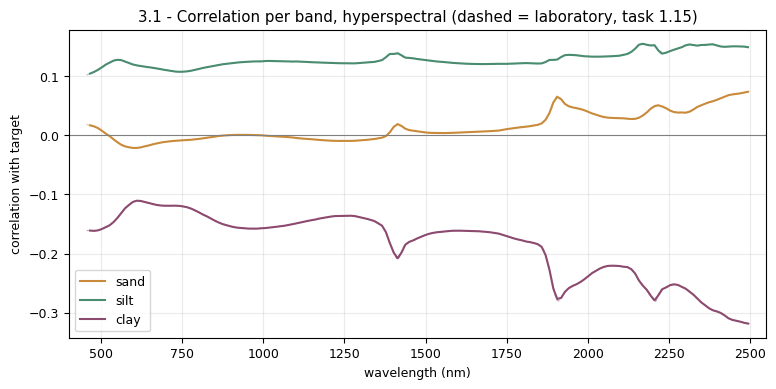

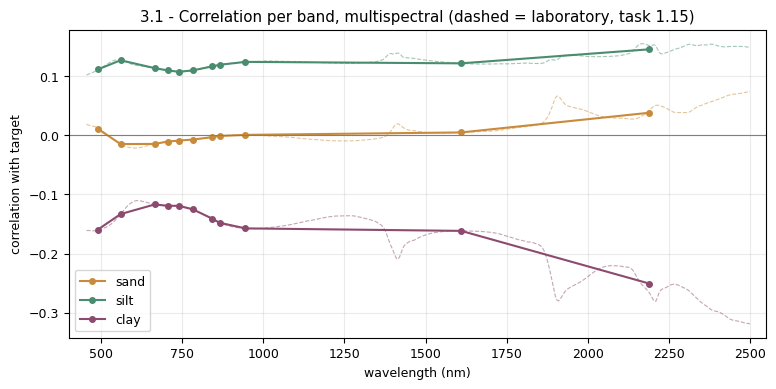

In [15]:
# task 3.1: the same correlation curves, on the simulated sensors
def corr_with_targets(df, cols, rows):
    """Pearson r of each column of df against sand, silt and clay."""
    return np.array([[np.corrcoef(df.loc[rows, c], dataset.loc[rows, t])[0, 1]
                      for t in TARGETS] for c in cols])

R_lab = corr_with_targets(dataset, SPEC410, VALID)
R_hyper = corr_with_targets(hyper, HYPER_OK, VALID)
R_multi = corr_with_targets(multi, MULTI_OK, VALID)

nm_hyper = np.array([c for n, c, w in BANDS_HYPER if n in HYPER_OK])
nm_multi = np.array([c for n, c, w in BANDS_12 if n in MULTI_OK])

for title, R_s, nm, style in [("hyperspectral", R_hyper, nm_hyper, "-"),
                              ("multispectral", R_multi, nm_multi, "o-")]:
    plt.figure(figsize=(9, 4))
    for k, t in enumerate(TARGETS):
        plt.plot(WL410, R_lab[:, k], lw=0.8, ls="--", color=COLORS[t], alpha=0.5)
        plt.plot(nm, R_s[:, k], style, ms=4, color=COLORS[t], label=t)
    plt.axhline(0, color="grey", lw=0.8)
    plt.xlim(400, 2550); plt.legend()
    plt.xlabel("wavelength (nm)"); plt.ylabel("correlation with target")
    plt.title(f"3.1 - Correlation per band, {title} (dashed = laboratory, task 1.15)")
    save_fig(f"3.1_{title}"); plt.show()

In [16]:
# task 3.2: how much of the laboratory correlation each sensor keeps
rows = []
for k, t in enumerate(TARGETS):
    base = abs(R_lab[:, k]).max()
    for sensor, R_s, nm in [("hyperspectral", R_hyper, nm_hyper),
                            ("multispectral", R_multi, nm_multi)]:
        best = np.argmax(abs(R_s[:, k]))
        kept = abs(R_s[best, k]) / base
        rows.append({"target": t, "sensor": sensor,
                     "lab_peak_r": round(base, 3),
                     "sensor_peak_r": round(abs(R_s[best, k]), 3),
                     "peak_nm": nm[best],
                     "kept": round(kept, 2),
                     "survived": "yes" if kept > 0.9 else "partly" if kept > 0.6 else "no"})

table_32 = pd.DataFrame(rows)
table_32.to_csv("tables/table_3_2.csv", index=False)

print("multispectral bands cover:", nm_multi.min(), "-", nm_multi.max(), "nm")
print("laboratory peaks sit at   :",
      {t: int(WL410[np.argmax(abs(R_lab[:, k]))]) for k, t in enumerate(TARGETS)})
table_32

multispectral bands cover: 490 - 2190 nm
laboratory peaks sit at   : {'sand': 2500, 'silt': 2170, 'clay': 2500}


,target,sensor,lab_peak_r,sensor_peak_r,peak_nm,kept,survived
0,sand,hyperspectral,0.074,0.074,2494,0.99,yes
1,sand,multispectral,0.074,0.038,2190,0.51,no
2,silt,hyperspectral,0.155,0.155,2170,1.00,yes
3,silt,multispectral,0.155,0.145,2190,0.94,yes
4,clay,hyperspectral,0.319,0.318,2494,1.00,yes
5,clay,multispectral,0.319,0.251,2190,0.79,partly


#### 3.2 - A reason for every cell

| target | sensor | survived | why |
|---|---|---|---|
| sand | hyperspectral | **yes** (99%) | Sand's peak sits at 2500 nm and the 12 nm grid still samples it, at 2494 nm. Nothing is lost because nothing was narrow. |
| sand | multispectral | **no** (51%) | Sand peaks at **2500 nm, and the multispectral sensor stops at 2280 nm** - the peak region is simply never measured. The best remaining band, B12, carries half the correlation. |
| silt | hyperspectral | **yes** (100%) | Peak preserved exactly at 2170 nm. |
| silt | multispectral | **yes** (94%) | Luck of the layout: silt's 2170 nm peak falls almost exactly on B12's centre (2190 nm), so one wide band lands right on the signal. |
| clay | hyperspectral | **yes** (100%) | Peak preserved at 2494 nm; the 2200 nm feature keeps 82% of its depth (task 2.4). |
| clay | multispectral | **partly** (79%) | Both of clay's routes are damaged: its 2500 nm peak is out of range, and B12's 180 nm width erases the 2200 nm feature completely (depth 0.0203 -> 0.0000). What survives is not the mineral feature but clay's broad correlation with overall brightness, which any band can see. |

**Caveat.** This measures only what a *linear, single-band* correlation can see. A model
uses combinations of bands, so a "no" here does not prove a model must fail - section 5 may
beat this table, and that would be a result rather than a mistake.

### 3.3 - Predictions, written before any model is fitted

**Deliverable:** 3 written lines. *Locked - not to be modified once section 4 has run.*

1. **Clay will be the easiest.** It has the strongest laboratory correlation of the three
   (|r| = 0.32 pooled, up to 0.61 inside a single programme) and a real physical cause -
   clay minerals absorb near 2200 nm - rather than a statistical accident.
2. **Sand will be the hardest.** Its pooled correlation is barely above zero (|r| = 0.074)
   and it has no absorption feature of its own; sand is mostly inferred as whatever is left
   once silt and clay are accounted for.
3. **Sand loses most going from hyperspectral to multispectral**, falling from 99% of the
   laboratory correlation to 51%, because its 2500 nm peak lies beyond the sensor's last
   band. Clay loses more in absolute terms (0.319 -> 0.251) but keeps a usable signal;
   silt barely notices, since B12 happens to sit on its peak.

I also expect **hyperspectral to be almost indistinguishable from the laboratory spectra**:
it retains 99-100% of every correlation, and section 1 showed one component already explains
95% of 410 columns, so 170 bands cannot be a meaningful bottleneck.